In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


In [8]:
df.shape

(400, 5)

In [9]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

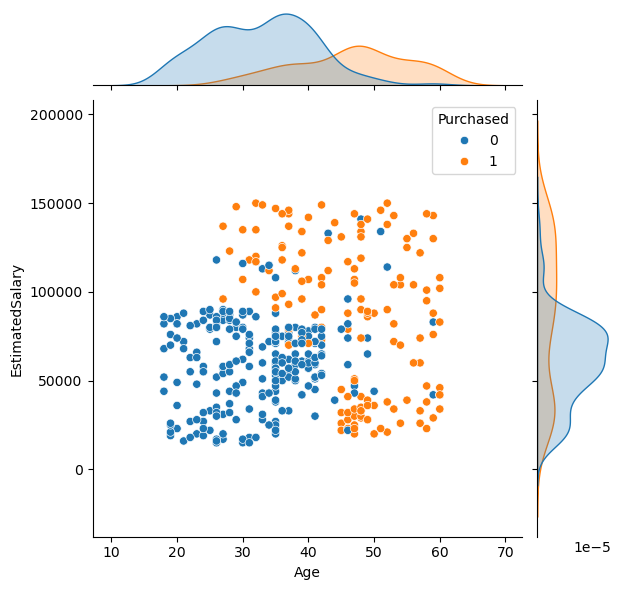

In [10]:
sns.jointplot(x = 'Age', y = 'EstimatedSalary', data = df, hue = 'Purchased');

In [11]:
x = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

<Axes: xlabel='Purchased', ylabel='count'>

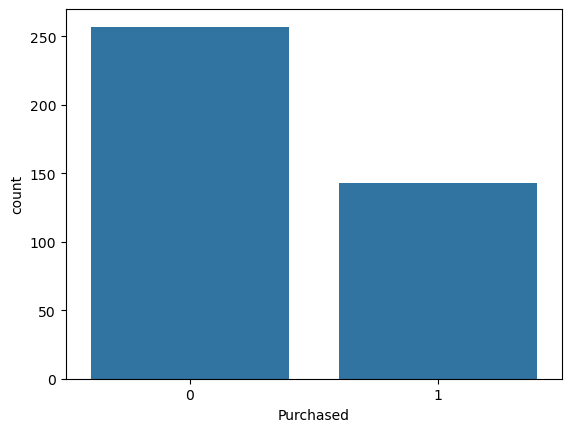

In [12]:
sns.countplot(x = 'Purchased', data = df)

In [13]:
print(df['Purchased'].value_counts())

Purchased
0    257
1    143
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 0)

In [16]:
from sklearn.preprocessing import MinMaxScaler
sca = MinMaxScaler()

In [17]:
x_train_scaled = sca.fit_transform(x_train)
x_test_scaled = sca .transform(x_test)

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
rf = RandomForestClassifier(random_state = 0, n_estimators = 50)

In [20]:
rf.fit(x_train_scaled, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred = rf.predict(x_test_scaled)

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.92

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

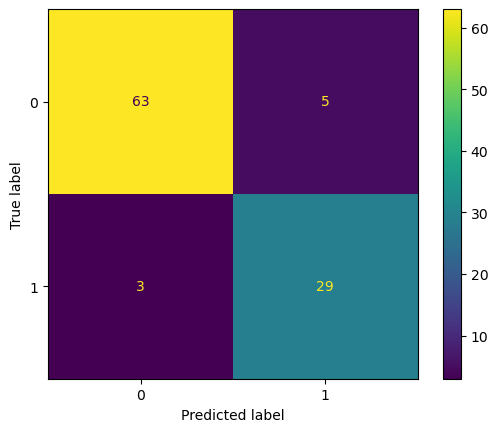

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

In [25]:
print(classification_report(y_test, y_pred));

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        68
           1       0.85      0.91      0.88        32

    accuracy                           0.92       100
   macro avg       0.90      0.92      0.91       100
weighted avg       0.92      0.92      0.92       100



In [26]:
rf.feature_importances_

array([0.50052967, 0.49947033])

In [27]:
rf.estimators_

[DecisionTreeClassifier(max_features='sqrt', random_state=209652396),
 DecisionTreeClassifier(max_features='sqrt', random_state=398764591),
 DecisionTreeClassifier(max_features='sqrt', random_state=924231285),
 DecisionTreeClassifier(max_features='sqrt', random_state=1478610112),
 DecisionTreeClassifier(max_features='sqrt', random_state=441365315),
 DecisionTreeClassifier(max_features='sqrt', random_state=1537364731),
 DecisionTreeClassifier(max_features='sqrt', random_state=192771779),
 DecisionTreeClassifier(max_features='sqrt', random_state=1491434855),
 DecisionTreeClassifier(max_features='sqrt', random_state=1819583497),
 DecisionTreeClassifier(max_features='sqrt', random_state=530702035),
 DecisionTreeClassifier(max_features='sqrt', random_state=626610453),
 DecisionTreeClassifier(max_features='sqrt', random_state=1650906866),
 DecisionTreeClassifier(max_features='sqrt', random_state=1879422756),
 DecisionTreeClassifier(max_features='sqrt', random_state=1277901399),
 DecisionTree

In [28]:
#Bagging of KNN

In [29]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)

In [30]:
knn.fit(x_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
y_pred = knn.predict(x_test_scaled)

In [32]:
from sklearn.metrics import accuracy_score

In [33]:
accuracy = accuracy_score(y_test, y_pred)

In [34]:
accuracy

0.93

In [35]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(KNeighborsClassifier(n_neighbors = 5), random_state = 0, n_estimators = 50)

In [36]:
bag.fit(x_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,n_estimators,50
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,0
,verbose,0


In [37]:
y_pred = bag.predict(x_test_scaled)

In [38]:
accuracy = accuracy_score(y_test, y_pred)

In [39]:
accuracy

0.93

In [40]:
data = pd.read_csv('train.csv')

In [41]:
data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [42]:
data.shape

(2000, 21)

In [43]:
data.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [45]:
x = data.drop('price_range', axis = 1)
y = data['price_range']

In [46]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 0)

In [50]:
model = LogisticRegression(max_iter = 1000)
model.fit(x_train, y_train)

C:\Users\shrus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [51]:
y_pred = model.predict(x_test)

In [52]:
accuracy_score(y_test, y_pred)

0.705

In [53]:
confusion_matrix(y_test, y_pred)

array([[84, 11,  0,  0],
       [11, 60, 21,  0],
       [ 0, 19, 56, 24],
       [ 0,  1, 31, 82]])

In [55]:
print(classification_report(y_test, y_pred));

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        95
           1       0.66      0.65      0.66        92
           2       0.52      0.57      0.54        99
           3       0.77      0.72      0.75       114

    accuracy                           0.70       400
   macro avg       0.71      0.71      0.71       400
weighted avg       0.71      0.70      0.71       400

